In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import pandas as pd
import os
import sys
from pathlib import Path
from scipy.stats import gaussian_kde

sys.path.append(str(Path.cwd().parent))

from _utils._utils_spline import eval_spline_basis_equispaced_numeric
from _run._run_generate_distortion_data_01 import max_ratio_cd, max_ratio_cond, plot_max_ratio_cond, plot_max_ratio_cond_implementation

In [2]:
okabe_ito_colors = np.array(["#000000", "#E69F00", "#56B4E9", "#009E73", "#F0E442",
          "#0072B2","#D55E00", "#CC79A7", "#999999"])

In [62]:
###
data_dict_path = os.path.join("../data", "data_dictQ.pkl")
with open(data_dict_path, "rb") as f:
    data_dict = pickle.load(f)

In [3]:
###
data_dict_path = os.path.join("../data", "data_dictQ_01.pkl")
with open(data_dict_path, "rb") as f:
    data_dict = pickle.load(f)

In [4]:
def I(n):
    return np.eye(n)
def e(m, j):
    e = np.zeros((m, 1))
    e[j-1] = 1
    return e
def P(a, b=None):
    if b is None:
        return I(a) - np.ones((a, 1)) @ np.ones((a, 1)).T/a
    else:
        l = np.shape(a)[0]
        return I(l) - (b @ a.T)/(a.T @ b)
def R(m, j):
    return P(e(m, j), np.ones((m, 1)))

def C(B):
    n, k = B.shape
    return P(B.T@np.ones((n, 1)), np.ones((k, 1)))

def max_ratio_conditioning(B):
    k = B.shape[1]
    w = C(B).T @ np.ones((k, 1))
    return w / np.linalg.norm(w, 2), np.linalg.norm(w, 2)

In [48]:
def plot_max_ratio_conditioning(data_dict, n_list, replication_list, distribution, num_knots):
    fig, ax = plt.subplots(figsize=(6, 4))

    for dist in distribution:
        for n in n_list:
            for r in replication_list:
                x = data_dict[(dist, n, r)]

                degree = 3
                x_vals = x.copy()
                x_plot = np.linspace(np.min(x_vals), np.max(x_vals), 100)

                B = eval_spline_basis_equispaced_numeric(
                    degree, np.min(x_vals), np.max(x_vals), num_knots, x_vals
                )['B']
                B_plot = eval_spline_basis_equispaced_numeric(
                    degree, np.min(x_vals), np.max(x_vals), num_knots, x_plot
                )['B']

                v, pen = max_ratio_conditioning(B)

                #ax.plot(x_plot, (B_plot @ v) - np.ones((len(x_plot), 1))*np.ones((len(x_vals), 1)).T@(B @ v), label=f'{dist}, {n}, {r}')
                ax.plot(x_plot, P(len(x_plot))@(B_plot @ v), label=f'{dist}, {n}, {r}')

    ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1))

    return fig, ax

def plot_max_ratio_conditioning_implementation(data_dict, n_list, replication_list,
                                       distribution, num_knots):
    fig, ax = plt.subplots(figsize=(6, 4))

    # Assign one color per distribution
    cmap = plt.get_cmap("tab10")
    colors = {dist: cmap(i) for i, dist in enumerate(distribution)}

    for dist in distribution:
        color = colors[dist]

        for n in n_list:
            for r in replication_list:
                x = data_dict[(dist, n, r)]

                degree = 3
                x_vals = x.copy()
                x_plot = np.linspace(np.min(x_vals), np.max(x_vals), 100)

                B = eval_spline_basis_equispaced_numeric(
                    degree, np.min(x_vals), np.max(x_vals), num_knots, x_vals
                )['B']
                B_plot = eval_spline_basis_equispaced_numeric(
                    degree, np.min(x_vals), np.max(x_vals), num_knots, x_plot
                )['B']

                v, pen = max_ratio_conditioning(B)

                # Only label the first line for each distribution
                label = dist if (n == n_list[0] and r == replication_list[0]) else None

                ax.plot(
                    x_plot,
                    P(len(x_plot)) @ (B_plot @ v),
                    color=color,
                    alpha=0.5,
                    label=label,
                )

    ax.legend(title="Distribution", loc="upper left", bbox_to_anchor=(1.05, 1))

    return fig, ax


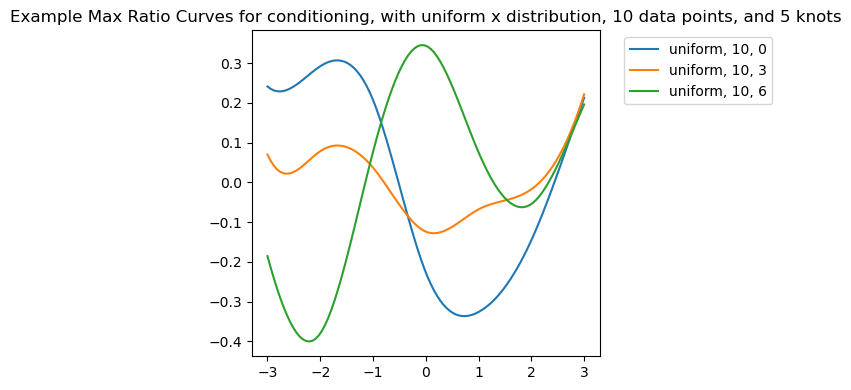

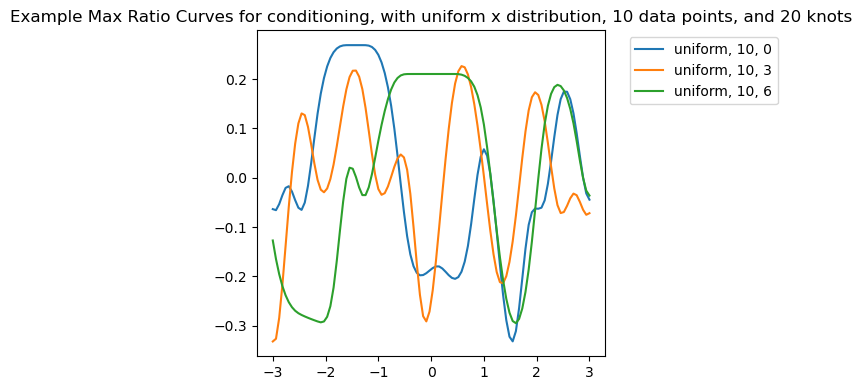

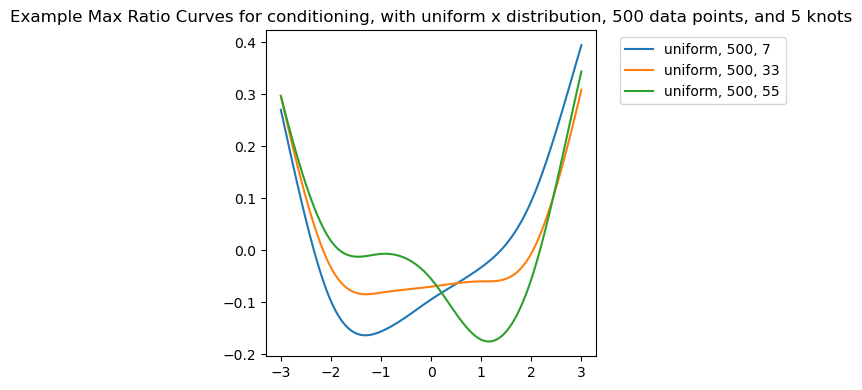

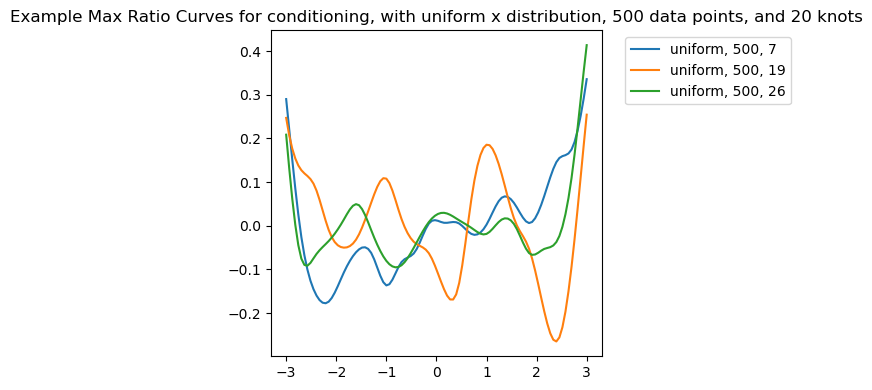

In [59]:
# with fewer data points the x distribution is more varied, so we can see the effect of the distribution on the distortion more clearly.
from _run._run_generate_distortion_data import plot_max_ratio_cond


n_l = [10]
replication_l = [0, 3, 6]
dist = ['uniform']
num_k = 5

fig, ax = plot_max_ratio_conditioning(data_dict, n_l, replication_l, dist, num_k)

ax.set_title(f"Example Max Ratio Curves for conditioning, with {dist[0]} x distribution, {n_l[0]} data points, and {num_k} knots")
fig.tight_layout()
plt.show()

# with fewer data points the x distribution is more varied, so we can see the effect of the distribution on the distortion more clearly.
n_l = [10]
replication_l = [0, 3, 6]
dist = ['uniform']
num_k = 20

fig, ax = plot_max_ratio_conditioning(data_dict, n_l, replication_l, dist, num_k)

ax.set_title(f"Example Max Ratio Curves for conditioning, with {dist[0]} x distribution, {n_l[0]} data points, and {num_k} knots")
fig.tight_layout()
plt.show()

# with fewer data points the x distribution is more varied, so we can see the effect of the distribution on the distortion more clearly.
n_l = [500]
replication_l = [7, 33, 55]
dist = ['uniform']
num_k = 5

fig, ax = plot_max_ratio_conditioning(data_dict, n_l, replication_l, dist, num_k)

ax.set_title(f"Example Max Ratio Curves for conditioning, with {dist[0]} x distribution, {n_l[0]} data points, and {num_k} knots")
fig.tight_layout()
plt.show()

# with fewer data points the x distribution is more varied, so we can see the effect of the distribution on the distortion more clearly.
n_l = [500]
replication_l = [7, 19, 26]
dist = ['uniform']
num_k = 20

fig, ax = plot_max_ratio_conditioning(data_dict, n_l, replication_l, dist, num_k)

ax.set_title(f"Example Max Ratio Curves for conditioning, with {dist[0]} x distribution, {n_l[0]} data points, and {num_k} knots")
fig.tight_layout()
plt.show()

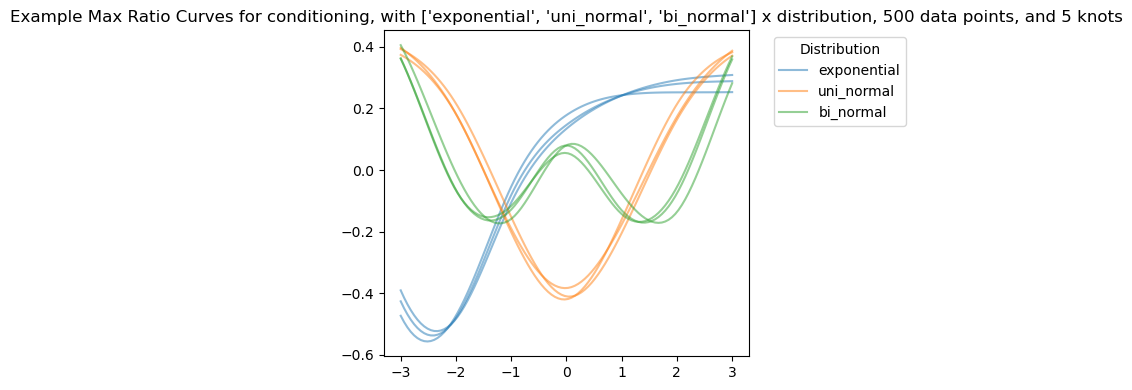

In [66]:
# with more data points, the difference between x distributions is clearer
n_l = [500]
replication_l = [0, 1, 2]
dist = ['exponential', 'uni_normal', 'bi_normal']
num_k = 5

fig, ax = plot_max_ratio_conditioning_implementation(data_dict, n_l, replication_l, dist, num_k)

ax.set_title(f"Example Max Ratio Curves for conditioning, with {dist} x distribution, {n_l[0]} data points, and {num_k} knots")
fig.tight_layout()
plt.show()

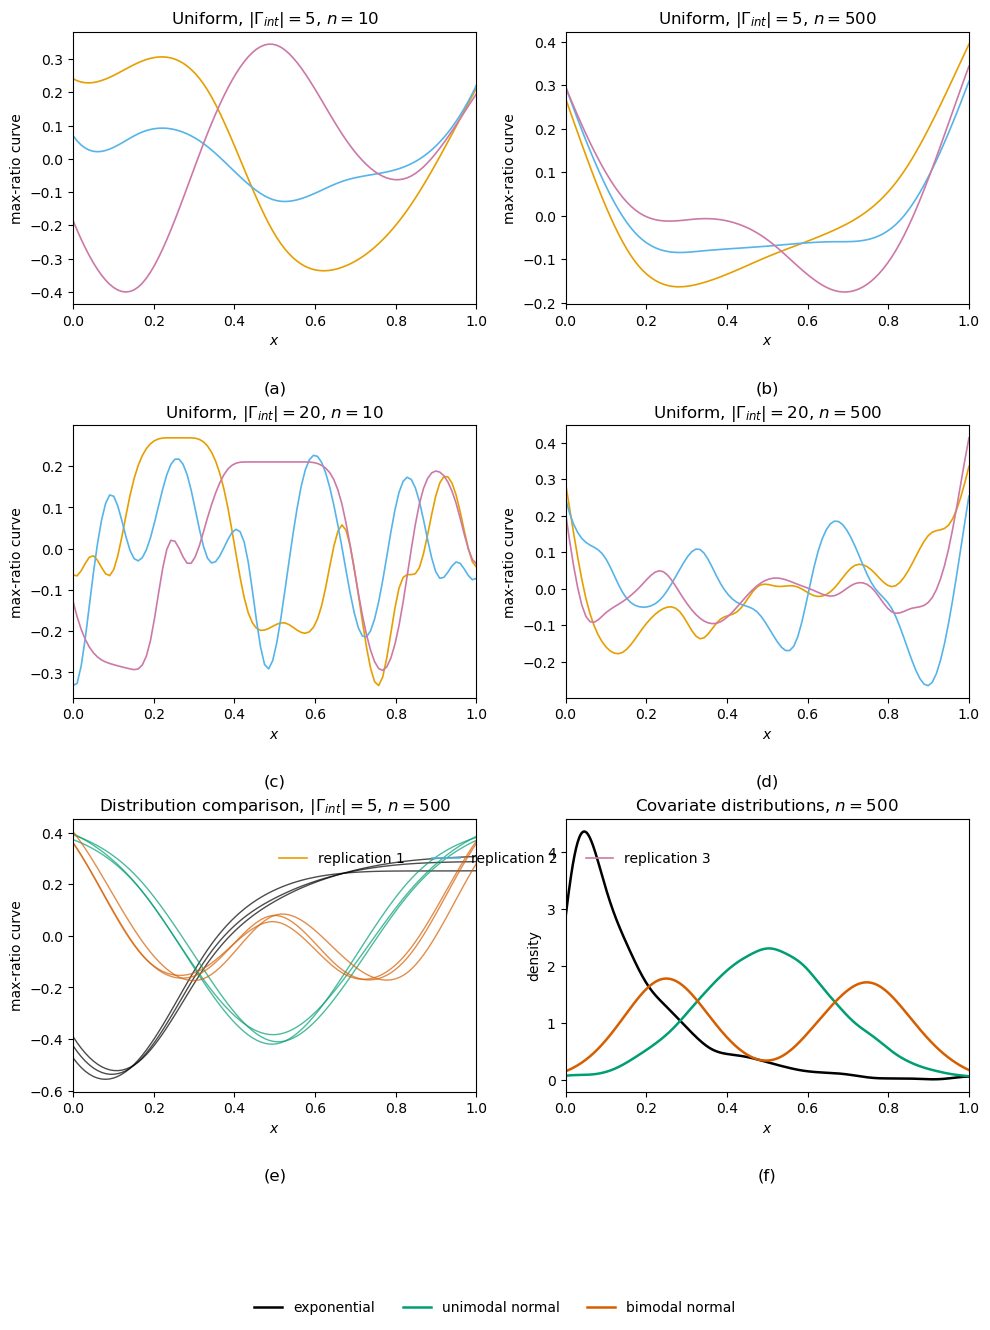

In [95]:
# -------------------------------------------------------------------
# Helpers
# -------------------------------------------------------------------

def rescale_01(x):
    """Rescale x to the interval [0, 1]."""
    x = np.asarray(x)

    x_min = np.min(x)
    x_max = np.max(x)

    if x_max == x_min:
        return np.zeros_like(x)

    return (x - x_min) / (x_max - x_min)


def get_all_replications(data_dict, dist, n):
    """
    Return all replication indices available for a given
    distribution and sample size.
    """
    return sorted([
        r
        for (d, n_i, r) in data_dict.keys()
        if d == dist and n_i == n
    ])[0:5]


def get_max_ratio_curve(x, num_knots, n_plot=100):
    """
    Construct the maximum-ratio curve for a sample x.

    The observed x values are rescaled to [0, 1], and the spline
    basis is constructed on [0, 1].
    """
    degree = 3

    x_vals = rescale_01(x)
    x_plot = np.linspace(0, 1, n_plot)

    B = eval_spline_basis_equispaced_numeric(
        degree,
        0,
        1,
        num_knots,
        x_vals,
    )["B"]

    B_plot = eval_spline_basis_equispaced_numeric(
        degree,
        0,
        1,
        num_knots,
        x_plot,
    )["B"]

    v, pen = max_ratio_conditioning(B)

    curve = P(len(x_plot)) @ (B_plot @ v)

    return x_plot, np.asarray(curve).squeeze()


# -------------------------------------------------------------------
# Main figure
# -------------------------------------------------------------------

def plot_max_ratio_six_panel(data_dict):
    """
    Create a six-panel figure:

        (a) Uniform, $|\Gamma_{int}|=5$, n=10, replications [0, 3, 6]
        (b) Uniform, $|\Gamma_{int}|=5$, n=500, replications [7, 33, 55]

        (c) Uniform, $|\Gamma_{int}|=20$, n=10, replications [0, 3, 6]
        (d) Uniform, $|\Gamma_{int}|=20$, n=500, replications [7, 19, 26]

        (e) Exponential, unimodal normal, and bimodal normal,
            n=500, replications [0, 1, 2]

        (f) Density histograms for all replications of exponential,
            unimodal normal, and bimodal normal, n=500.

    Colours:
        Panels (a)-(d): okabe_ito_colors[1], [2], [3]
        Panels (e)-(f): okabe_ito_colors[4], [5], [6]
    """

    # ---------------------------------------------------------------
    # Labels
    # ---------------------------------------------------------------

    dist_labels = {
        "uniform": "uniform",
        "exponential": "exponential",
        "uni_normal": "unimodal normal",
        "bi_normal": "bimodal normal",
    }

    # ---------------------------------------------------------------
    # Colours
    # ---------------------------------------------------------------

    okabe_ito_colors = np.array(["#000000", "#E69F00", "#56B4E9", "#009E73", "#F0E442",
          "#0072B2","#D55E00", "#CC79A7", "#999999"])
    
    # Three fixed colours for the three selected uniform replications
    replication_colors = [
        okabe_ito_colors[1],
        okabe_ito_colors[2],
        okabe_ito_colors[7],
    ]
    

    # Fixed colour for each distribution in panels (e) and (f)
    distribution_colors = {
        "exponential": okabe_ito_colors[0],
        "uni_normal": okabe_ito_colors[3],
        "bi_normal": okabe_ito_colors[6],
    }

    comparison_distributions = [
        "exponential",
        "uni_normal",
        "bi_normal",
    ]

    # ---------------------------------------------------------------
    # Exact replications specified in your original code
    # ---------------------------------------------------------------

    # Uniform, n = 10
    uniform_replications_n10 = [0, 3, 6]

    # Uniform, n = 500, $|\Gamma_{int}|=5$
    uniform_replications_n500_5knots = [7, 33, 55]

    # Uniform, n = 500, $|\Gamma_{int}|=20$
    uniform_replications_n500_20knots = [7, 19, 26]

    # Distribution comparison
    comparison_replications = [0, 1, 2]

    # ---------------------------------------------------------------
    # Figure
    # ---------------------------------------------------------------

    fig, axes = plt.subplots(
        3,
        2,
        figsize=(10, 13),
    )

    ax_a, ax_b = axes[0]
    ax_c, ax_d = axes[1]
    ax_e, ax_f = axes[2]

    panel_labels = ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)"]

    # ===============================================================
    # Panels (a)-(d): uniform distribution
    # ===============================================================

    uniform_settings = [
        {
            "ax": ax_a,
            "n": 10,
            "num_knots": 5,
            "replications": uniform_replications_n10,
        },
        {
            "ax": ax_b,
            "n": 500,
            "num_knots": 5,
            "replications": uniform_replications_n500_5knots,
        },
        {
            "ax": ax_c,
            "n": 10,
            "num_knots": 20,
            "replications": uniform_replications_n10,
        },
        {
            "ax": ax_d,
            "n": 500,
            "num_knots": 20,
            "replications": uniform_replications_n500_20knots,
        },
    ]

    uniform_legend_handles = []

    for panel_index, settings in enumerate(uniform_settings):

        ax = settings["ax"]
        n = settings["n"]
        num_knots = settings["num_knots"]
        replications = settings["replications"]

        for i, r in enumerate(replications):

            x = data_dict[("uniform", n, r)]

            x_plot, curve = get_max_ratio_curve(
                x,
                num_knots=num_knots,
            )

            color = replication_colors[i]

            # Add legend handles only once
            label = None
            if panel_index == 0:
                label = f"replication {r}"

            line, = ax.plot(
                x_plot,
                curve,
                color=color,
                alpha=1.0,
                linewidth=1.2,
                label=label,
            )

            if panel_index == 0:
                uniform_legend_handles.append(line)

        ax.set_xlim(0, 1)

        ax.set_xlabel(r"$x$")
        ax.set_ylabel("max-ratio curve")

        ax.set_title(
            f"Uniform, $|\Gamma_{{int}}|={num_knots}$, $n={n}$"
        )

        # Panel label below plot
        ax.text(
            0.5,
            -0.28,
            panel_labels[panel_index],
            transform=ax.transAxes,
            ha="center",
            va="top",
            fontsize=12,
        )

    # ===============================================================
    # First legend: selected replications
    # ===============================================================

    fig.legend(
        handles=uniform_legend_handles,
        labels=[
            "replication 1",
            "replication 2",
            "replication 3",
        ],
        loc="center",
        bbox_to_anchor=(0.5, 0.335),
        ncol=3,
        frameon=False,
    )

    # ===============================================================
    # Panel (e): three selected replications for each distribution
    # ===============================================================

    distribution_legend_handles = []

    for dist in comparison_distributions:

        color = distribution_colors[dist]

        for r in comparison_replications:

            x = data_dict[(dist, 500, r)]

            x_plot, curve = get_max_ratio_curve(
                x,
                num_knots=5,
            )

            line, = ax_e.plot(
                x_plot,
                curve,
                color=color,
                alpha=0.7,
                linewidth=1.0,
            )

        # Dummy line used for the distribution legend
        legend_line, = ax_e.plot(
            [],
            [],
            color=color,
            linewidth=1.8,
            label=dist_labels[dist],
        )

        distribution_legend_handles.append(legend_line)

    ax_e.set_xlim(0, 1)

    ax_e.set_xlabel(r"$x$")
    ax_e.set_ylabel("max-ratio curve")

    ax_e.set_title(
        r"Distribution comparison, $|\Gamma_{int}|=5$, $n=500$"
    )

    ax_e.text(
        0.5,
        -0.28,
        panel_labels[4],
        transform=ax_e.transAxes,
        ha="center",
        va="top",
        fontsize=12,
    )

    # ===============================================================
    # Panel (f): histograms using ALL replications
    # ===============================================================

    for dist in comparison_distributions:

        # Here we deliberately use ALL available replications
        replications = get_all_replications(
            data_dict,
            dist=dist,
            n=500,
        )

        # Rescale every replication individually, then pool them
        x_all = np.concatenate([
            rescale_01(data_dict[(dist, 500, r)])
            for r in replications
        ])

        smooth = True  # Set to True for KDE, False for histogram
        if smooth:
            kde = gaussian_kde(x_all)
            x_grid = np.linspace(0, 1, 500)
            ax_f.plot(
                x_grid,
                kde(x_grid),
                linewidth=1.8,
                color=distribution_colors[dist],
            )
        else:
            ax_f.hist(
                x_all,
                bins=30,
                density=True,
                histtype="step",
                linewidth=1.8,
                color=distribution_colors[dist],
            )

    ax_f.set_xlim(0, 1)

    ax_f.set_xlabel(r"$x$")
    ax_f.set_ylabel("density")

    ax_f.set_title(
        r"Covariate distributions, $n=500$"
    )

    ax_f.text(
        0.5,
        -0.28,
        panel_labels[5],
        transform=ax_f.transAxes,
        ha="center",
        va="top",
        fontsize=12,
    )

    # ===============================================================
    # Second legend: distributions
    # ===============================================================

    fig.legend(
        handles=distribution_legend_handles,
        labels=[
            dist_labels[dist]
            for dist in comparison_distributions
        ],
        loc="lower center",
        bbox_to_anchor=(0.5, -0.025),
        ncol=3,
        frameon=False,
    )

    # ---------------------------------------------------------------
    # Spacing
    # ---------------------------------------------------------------

    fig.subplots_adjust(
        hspace=0.75,
        wspace=0.30,
        bottom=0.10,
        top=0.95,
    )

    return fig, axes


# -------------------------------------------------------------------
# Create figure
# -------------------------------------------------------------------

fig, axes = plot_max_ratio_six_panel(data_dict)

# Leave room for the legend
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig("figure_conditioning_max.pdf", bbox_inches="tight", dpi=300)

plt.show()

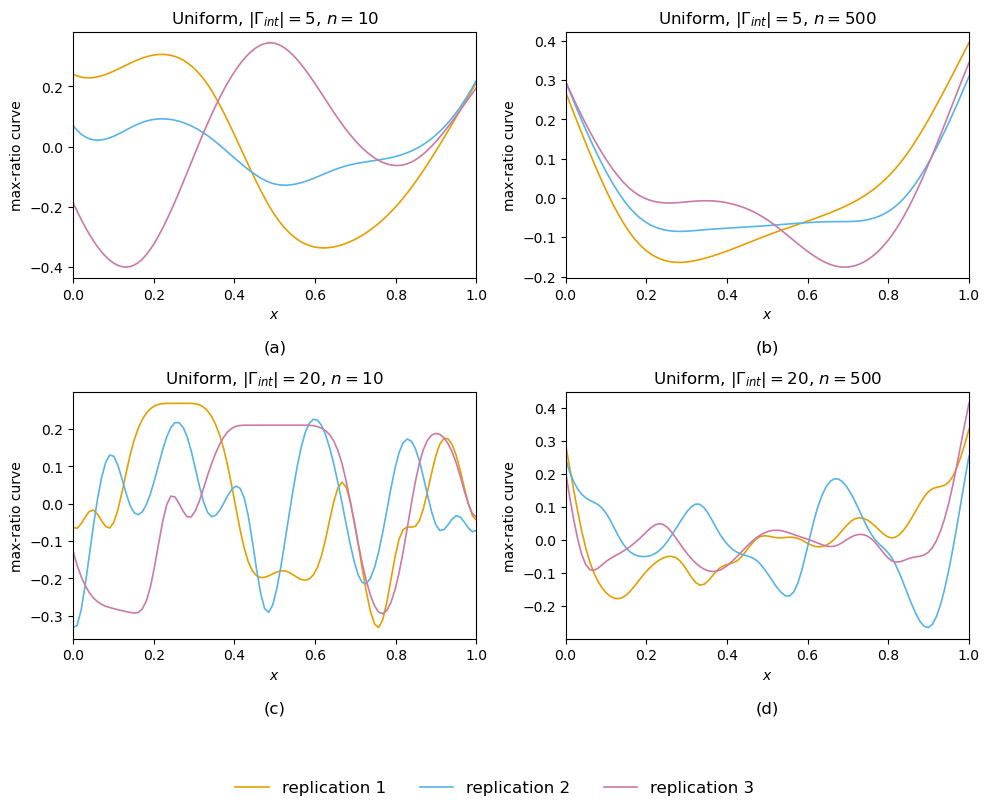

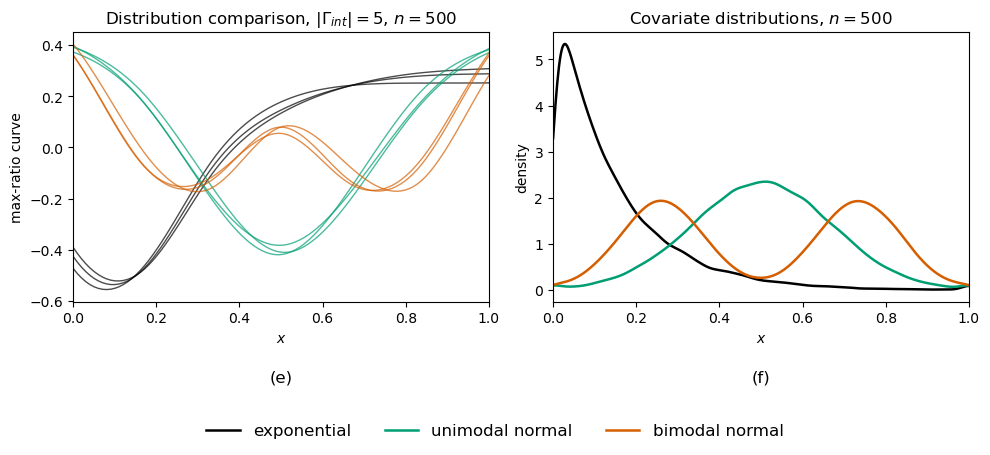

In [96]:
# -------------------------------------------------------------------
# Helpers
# -------------------------------------------------------------------

def rescale_01(x):
    """Rescale x to the interval [0, 1]."""
    x = np.asarray(x)

    x_min = np.min(x)
    x_max = np.max(x)

    if x_max == x_min:
        return np.zeros_like(x)

    return (x - x_min) / (x_max - x_min)


def get_all_replications(data_dict, dist, n):
    """Return all replication indices available for a distribution and n."""
    rep = [
        r
        for (d, n_i, r) in data_dict.keys()
        if d == dist and n_i == n
    ]
    return sorted(rep)[:]


def get_max_ratio_curve(x, num_knots, n_plot=100):
    """Construct the rescaled maximum-ratio curve."""
    degree = 3

    x_vals = rescale_01(x)
    x_plot = np.linspace(0, 1, n_plot)

    B = eval_spline_basis_equispaced_numeric(
        degree, 0, 1, num_knots, x_vals
    )["B"]

    B_plot = eval_spline_basis_equispaced_numeric(
        degree, 0, 1, num_knots, x_plot
    )["B"]

    v, _ = max_ratio_conditioning(B)

    curve = P(len(x_plot)) @ (B_plot @ v)

    return x_plot, np.asarray(curve).squeeze()


# -------------------------------------------------------------------
# Colours and labels
# -------------------------------------------------------------------

okabe_ito_colors = np.array([
    "#000000", "#E69F00", "#56B4E9", "#009E73", "#F0E442",
    "#0072B2", "#D55E00", "#CC79A7", "#999999"
])

replication_colors = [
    okabe_ito_colors[1],
    okabe_ito_colors[2],
    okabe_ito_colors[7],
]

distribution_colors = {
    "exponential": okabe_ito_colors[0],
    "uni_normal": okabe_ito_colors[3],
    "bi_normal": okabe_ito_colors[6],
}

dist_labels = {
    "exponential": "exponential",
    "uni_normal": "unimodal normal",
    "bi_normal": "bimodal normal",
}

comparison_distributions = [
    "exponential",
    "uni_normal",
    "bi_normal",
]


# -------------------------------------------------------------------
# Exact replications
# -------------------------------------------------------------------

uniform_replications_n10 = [0, 3, 6]
uniform_replications_n500_5knots = [7, 33, 55]
uniform_replications_n500_20knots = [7, 19, 26]

comparison_replications = [0, 1, 2]


# ===================================================================
# FIGURE 1: First two rows, four uniform-distribution plots
# ===================================================================

fig1, axes1 = plt.subplots(
    2,
    2,
    figsize=(10, 8),
)

ax_a, ax_b = axes1[0]
ax_c, ax_d = axes1[1]

panel_labels_1 = ["(a)", "(b)", "(c)", "(d)"]

uniform_settings = [
    {
        "ax": ax_a,
        "n": 10,
        "num_knots": 5,
        "replications": uniform_replications_n10,
    },
    {
        "ax": ax_b,
        "n": 500,
        "num_knots": 5,
        "replications": uniform_replications_n500_5knots,
    },
    {
        "ax": ax_c,
        "n": 10,
        "num_knots": 20,
        "replications": uniform_replications_n10,
    },
    {
        "ax": ax_d,
        "n": 500,
        "num_knots": 20,
        "replications": uniform_replications_n500_20knots,
    },
]

uniform_legend_handles = []

for panel_index, settings in enumerate(uniform_settings):

    ax = settings["ax"]
    n = settings["n"]
    num_knots = settings["num_knots"]
    replications = settings["replications"]

    for i, r in enumerate(replications):

        x = data_dict[("uniform", n, r)]

        x_plot, curve = get_max_ratio_curve(
            x,
            num_knots=num_knots,
        )

        color = replication_colors[i]

        label = None
        if panel_index == 0:
            label = f"replication {i + 1}"

        line, = ax.plot(
            x_plot,
            curve,
            color=color,
            alpha=1.0,
            linewidth=1.2,
            label=label,
        )

        if panel_index == 0:
            uniform_legend_handles.append(line)

    ax.set_xlim(0, 1)
    ax.set_xlabel(r"$x$")
    ax.set_ylabel("max-ratio curve")

    ax.set_title(
        f"Uniform, $|\Gamma_{{int}}|={num_knots}$, $n={n}$"
    )

    ax.text(
        0.5,
        -0.25,
        panel_labels_1[panel_index],
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=12,
    )


# Legend below the two rows
fig1.legend(
    handles=uniform_legend_handles,
    labels=[
        "replication 1",
        "replication 2",
        "replication 3",
    ],
    loc="lower center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=3,
    frameon=False,
    fontsize=12
)

fig1.subplots_adjust(
    hspace=0.60,
    wspace=0.30,
    bottom=0.15,
    top=0.95,
)


# ===================================================================
# FIGURE 2: Last row, distribution curves and histograms
# ===================================================================

fig2, axes2 = plt.subplots(
    1,
    2,
    figsize=(10, 4.5),
)

ax_e, ax_f = axes2

panel_labels_2 = ["(e)", "(f)"]


# -------------------------------------------------------------------
# Panel (e): selected replications for each distribution
# -------------------------------------------------------------------

distribution_legend_handles = []

for dist in comparison_distributions:

    color = distribution_colors[dist]

    for r in comparison_replications:

        x = data_dict[(dist, 500, r)]

        x_plot, curve = get_max_ratio_curve(
            x,
            num_knots=5,
        )

        ax_e.plot(
            x_plot,
            curve,
            color=color,
            alpha=0.7,
            linewidth=1.0,
        )

    # Handle for legend
    legend_line, = ax_e.plot(
        [],
        [],
        color=color,
        linewidth=1.8,
        label=dist_labels[dist],
    )

    distribution_legend_handles.append(legend_line)

ax_e.set_xlim(0, 1)
ax_e.set_xlabel(r"$x$")
ax_e.set_ylabel("max-ratio curve")

ax_e.set_title(
    r"Distribution comparison, $|\Gamma_{int}|=5$, $n=500$"
)

ax_e.text(
    0.5,
    -0.25,
    panel_labels_2[0],
    transform=ax_e.transAxes,
    ha="center",
    va="top",
    fontsize=12,
)


# -------------------------------------------------------------------
# Panel (f): histograms using ALL replications
# -------------------------------------------------------------------

for dist in comparison_distributions:

    # All available replications only for the histograms
    replications = get_all_replications(
        data_dict,
        dist=dist,
        n=500,
    )

    x_all = np.concatenate([
        rescale_01(data_dict[(dist, 500, r)])
        for r in replications
    ])

    smooth = True  # Set to True for KDE, False for histogram
    if smooth:
        kde = gaussian_kde(x_all)
        x_grid = np.linspace(0, 1, 500)
        ax_f.plot(
            x_grid,
            kde(x_grid),
            linewidth=1.8,
            color=distribution_colors[dist],
        )
    else:
        ax_f.hist(
            x_all,
            bins=30,
            density=True,
            histtype="step",
            linewidth=1.8,
            color=distribution_colors[dist],
        )

ax_f.set_xlim(0, 1)
ax_f.set_xlabel(r"$x$")
ax_f.set_ylabel("density")

ax_f.set_title(
    r"Covariate distributions, $n=500$"
)

ax_f.text(
    0.5,
    -0.25,
    panel_labels_2[1],
    transform=ax_f.transAxes,
    ha="center",
    va="top",
    fontsize=12,
)


# Distribution legend below the last row
fig2.legend(
    handles=distribution_legend_handles,
    labels=[
        dist_labels[dist]
        for dist in comparison_distributions
    ],
    loc="lower center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=3,
    frameon=False,
    fontsize=12
)

fig2.subplots_adjust(
    wspace=0.30,
    bottom=0.20,
    top=0.88,
)


# ===================================================================
# Save both figures temporarily, then combine into one image
# ===================================================================

fig1.tight_layout(rect=[0, 0.08, 1, 1])
fig1.savefig(
    "conditioning_top.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)
fig2.tight_layout(rect=[0, 0.08, 1, 1])
fig2.savefig(
    "conditioning_bottom.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)


# -------------------------------------------------------------------
# Combine the two figures vertically into one image
# -------------------------------------------------------------------

from PIL import Image

img_top = Image.open("conditioning_top.png").convert("RGB")
img_bottom = Image.open("conditioning_bottom.png").convert("RGB")

# Match widths while preserving aspect ratios
target_width = max(img_top.width, img_bottom.width)

if img_top.width != target_width:
    new_height = int(
        img_top.height * target_width / img_top.width
    )
    img_top = img_top.resize(
        (target_width, new_height),
        Image.Resampling.LANCZOS,
    )

if img_bottom.width != target_width:
    new_height = int(
        img_bottom.height * target_width / img_bottom.width
    )
    img_bottom = img_bottom.resize(
        (target_width, new_height),
        Image.Resampling.LANCZOS,
    )

# Small white gap between the two figures
gap = 30

combined_height = (
    img_top.height
    + gap
    + img_bottom.height
)

combined = Image.new(
    "RGB",
    (target_width, combined_height),
    "white",
)

combined.paste(img_top, (0, 0))
combined.paste(
    img_bottom,
    (0, img_top.height + gap),
)

combined.save(
    "figure_conditioning_max.png",
    dpi=(300, 300),
)

# Optional PDF version
combined.save(
    "figure_conditioning_max.pdf",
    resolution=300.0,
)

plt.show()

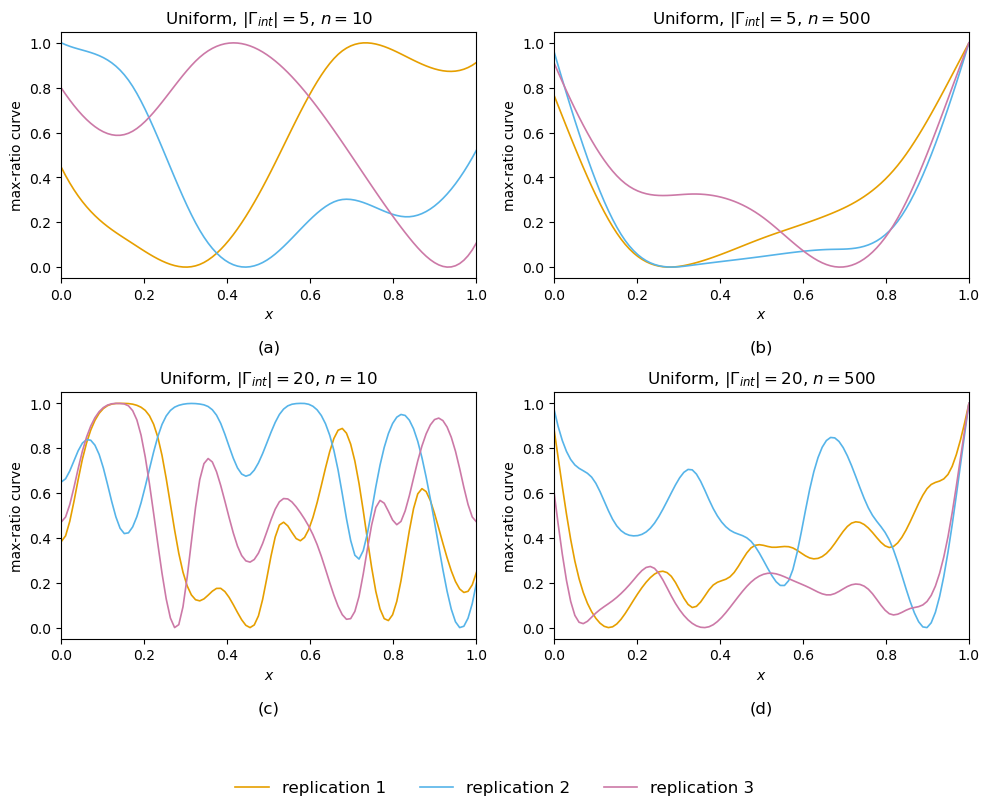

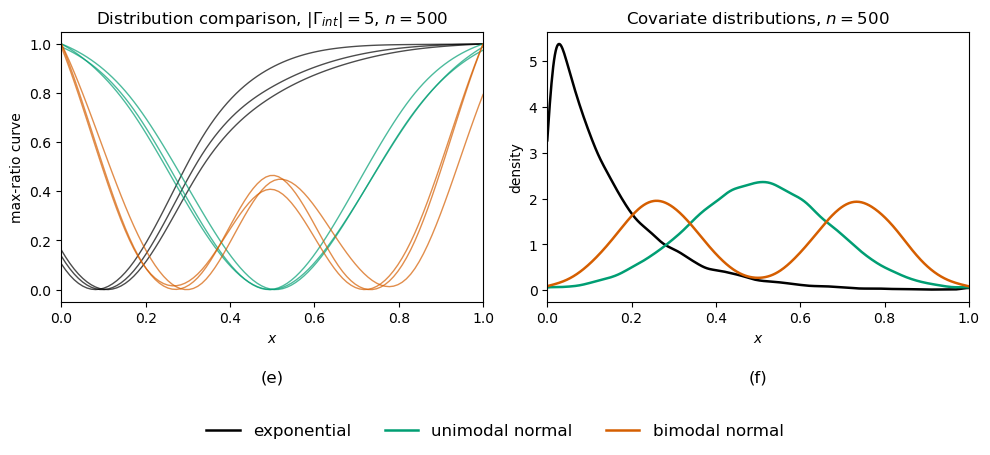

In [5]:
# -------------------------------------------------------------------
# Helpers
# -------------------------------------------------------------------

def rescale_01(x):
    """Rescale x to the interval [0, 1]."""
    x = np.asarray(x)

    x_min = np.min(x)
    x_max = np.max(x)

    if x_max == x_min:
        return np.zeros_like(x)
    return x
    return (x - x_min) / (x_max - x_min)


def get_all_replications(data_dict, dist, n):
    """Return all replication indices available for a distribution and n."""
    rep = [
        r
        for (d, n_i, r) in data_dict.keys()
        if d == dist and n_i == n
    ]
    return sorted(rep)[:]


def get_max_ratio_curve(x, num_knots, n_plot=100):
    """Construct the rescaled maximum-ratio curve."""
    degree = 3

    x_vals = rescale_01(x)
    x_plot = np.linspace(0, 1, n_plot)

    B = eval_spline_basis_equispaced_numeric(
        degree, 0, 1, num_knots, x_vals
    )["B"]

    B_plot = eval_spline_basis_equispaced_numeric(
        degree, 0, 1, num_knots, x_plot
    )["B"]

    v, _ = max_ratio_conditioning(B)
    curve = B_plot @ v
    curve = (curve - np.min(curve)) / (np.max(curve) - np.min(curve))
    # curve = P(len(x_plot)) @ curve

    return x_plot, np.asarray(curve).squeeze()


# -------------------------------------------------------------------
# Colours and labels
# -------------------------------------------------------------------

okabe_ito_colors = np.array([
    "#000000", "#E69F00", "#56B4E9", "#009E73", "#F0E442",
    "#0072B2", "#D55E00", "#CC79A7", "#999999"
])

replication_colors = [
    okabe_ito_colors[1],
    okabe_ito_colors[2],
    okabe_ito_colors[7],
]

distribution_colors = {
    "exponential": okabe_ito_colors[0],
    "uni_normal": okabe_ito_colors[3],
    "bi_normal": okabe_ito_colors[6],
}

dist_labels = {
    "exponential": "exponential",
    "uni_normal": "unimodal normal",
    "bi_normal": "bimodal normal",
}

comparison_distributions = [
    "exponential",
    "uni_normal",
    "bi_normal",
]


# -------------------------------------------------------------------
# Exact replications
# -------------------------------------------------------------------

uniform_replications_n10_5knots = [0 ,3, 6]#[0, 3, 6][7, 33, 55]
uniform_replications_n500_5knots = [7, 33, 55]
uniform_replications_n10_20knots = [3, 6, 23]#[7, 33, 55]
uniform_replications_n500_20knots = [7, 19, 26]

comparison_replications = [0, 1, 2]


# ===================================================================
# FIGURE 1: First two rows, four uniform-distribution plots
# ===================================================================

fig1, axes1 = plt.subplots(
    2,
    2,
    figsize=(10, 8),
)

ax_a, ax_b = axes1[0]
ax_c, ax_d = axes1[1]

panel_labels_1 = ["(a)", "(b)", "(c)", "(d)"]

uniform_settings = [
    {
        "ax": ax_a,
        "n": 10,
        "num_knots": 5,
        "replications": uniform_replications_n10_5knots,
    },
    {
        "ax": ax_b,
        "n": 500,
        "num_knots": 5,
        "replications": uniform_replications_n500_5knots,
    },
    {
        "ax": ax_c,
        "n": 10,
        "num_knots": 20,
        "replications": uniform_replications_n10_20knots,
    },
    {
        "ax": ax_d,
        "n": 500,
        "num_knots": 20,
        "replications": uniform_replications_n500_20knots,
    },
]

uniform_legend_handles = []

for panel_index, settings in enumerate(uniform_settings):

    ax = settings["ax"]
    n = settings["n"]
    num_knots = settings["num_knots"]
    replications = settings["replications"]

    for i, r in enumerate(replications):

        x = data_dict[("uniform", n, r)]

        x_plot, curve = get_max_ratio_curve(
            x,
            num_knots=num_knots,
        )

        color = replication_colors[i]

        label = None
        if panel_index == 0:
            label = f"replication {i + 1}"

        line, = ax.plot(
            x_plot,
            curve,
            color=color,
            alpha=1.0,
            linewidth=1.2,
            label=label,
        )

        if panel_index == 0:
            uniform_legend_handles.append(line)

    ax.set_xlim(0, 1)
    ax.set_xlabel(r"$x$")
    ax.set_ylabel("max-ratio curve")

    ax.set_title(
        f"Uniform, $|\Gamma_{{int}}|={num_knots}$, $n={n}$"
    )

    ax.text(
        0.5,
        -0.25,
        panel_labels_1[panel_index],
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=12,
    )


# Legend below the two rows
fig1.legend(
    handles=uniform_legend_handles,
    labels=[
        "replication 1",
        "replication 2",
        "replication 3",
    ],
    loc="lower center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=3,
    frameon=False,
    fontsize=12
)

fig1.subplots_adjust(
    hspace=0.60,
    wspace=0.30,
    bottom=0.15,
    top=0.95,
)


# ===================================================================
# FIGURE 2: Last row, distribution curves and histograms
# ===================================================================

fig2, axes2 = plt.subplots(
    1,
    2,
    figsize=(10, 4.5),
)

ax_e, ax_f = axes2

panel_labels_2 = ["(e)", "(f)"]


# -------------------------------------------------------------------
# Panel (e): selected replications for each distribution
# -------------------------------------------------------------------

distribution_legend_handles = []

for dist in comparison_distributions:

    color = distribution_colors[dist]

    for r in comparison_replications:

        x = data_dict[(dist, 500, r)]

        x_plot, curve = get_max_ratio_curve(
            x,
            num_knots=5,
        )

        ax_e.plot(
            x_plot,
            curve,
            color=color,
            alpha=0.7,
            linewidth=1.0,
        )

    # Handle for legend
    legend_line, = ax_e.plot(
        [],
        [],
        color=color,
        linewidth=1.8,
        label=dist_labels[dist],
    )

    distribution_legend_handles.append(legend_line)

ax_e.set_xlim(0, 1)
ax_e.set_xlabel(r"$x$")
ax_e.set_ylabel("max-ratio curve")

ax_e.set_title(
    r"Distribution comparison, $|\Gamma_{int}|=5$, $n=500$"
)

ax_e.text(
    0.5,
    -0.25,
    panel_labels_2[0],
    transform=ax_e.transAxes,
    ha="center",
    va="top",
    fontsize=12,
)


# -------------------------------------------------------------------
# Panel (f): histograms using ALL replications
# -------------------------------------------------------------------

for dist in comparison_distributions:

    # All available replications only for the histograms
    replications = get_all_replications(
        data_dict,
        dist=dist,
        n=500,
    )

    x_all = np.concatenate([
        rescale_01(data_dict[(dist, 500, r)])
        for r in replications
    ])

    smooth = True  # Set to True for KDE, False for histogram
    if smooth:
        kde = gaussian_kde(x_all)
        x_grid = np.linspace(0, 1, 500)
        ax_f.plot(
            x_grid,
            kde(x_grid),
            linewidth=1.8,
            color=distribution_colors[dist],
        )
    else:
        ax_f.hist(
            x_all,
            bins=30,
            density=True,
            histtype="step",
            linewidth=1.8,
            color=distribution_colors[dist],
        )

ax_f.set_xlim(0, 1)
ax_f.set_xlabel(r"$x$")
ax_f.set_ylabel("density")

ax_f.set_title(
    r"Covariate distributions, $n=500$"
)

ax_f.text(
    0.5,
    -0.25,
    panel_labels_2[1],
    transform=ax_f.transAxes,
    ha="center",
    va="top",
    fontsize=12,
)


# Distribution legend below the last row
fig2.legend(
    handles=distribution_legend_handles,
    labels=[
        dist_labels[dist]
        for dist in comparison_distributions
    ],
    loc="lower center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=3,
    frameon=False,
    fontsize=12
)

fig2.subplots_adjust(
    wspace=0.30,
    bottom=0.20,
    top=0.88,
)


# ===================================================================
# Save both figures temporarily, then combine into one image
# ===================================================================

fig1.tight_layout(rect=[0, 0.08, 1, 1])
fig1.savefig(
    "conditioning_top_01.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)
fig2.tight_layout(rect=[0, 0.08, 1, 1])
fig2.savefig(
    "conditioning_bottom_01.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)


# -------------------------------------------------------------------
# Combine the two figures vertically into one image
# -------------------------------------------------------------------

from PIL import Image

img_top = Image.open("conditioning_top_01.png").convert("RGB")
img_bottom = Image.open("conditioning_bottom_01.png").convert("RGB")

# Match widths while preserving aspect ratios
target_width = max(img_top.width, img_bottom.width)

if img_top.width != target_width:
    new_height = int(
        img_top.height * target_width / img_top.width
    )
    img_top = img_top.resize(
        (target_width, new_height),
        Image.Resampling.LANCZOS,
    )

if img_bottom.width != target_width:
    new_height = int(
        img_bottom.height * target_width / img_bottom.width
    )
    img_bottom = img_bottom.resize(
        (target_width, new_height),
        Image.Resampling.LANCZOS,
    )

# Small white gap between the two figures
gap = 30

combined_height = (
    img_top.height
    + gap
    + img_bottom.height
)

combined = Image.new(
    "RGB",
    (target_width, combined_height),
    "white",
)

combined.paste(img_top, (0, 0))
combined.paste(
    img_bottom,
    (0, img_top.height + gap),
)

combined.save(
    "figure_conditioning_max_01.png",
    dpi=(300, 300),
)

# Optional PDF version
combined.save(
    "figure_conditioning_max_01.pdf",
    resolution=300.0,
)

plt.show()